<a href="https://colab.research.google.com/github/nmwiley808/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project/blob/main/notebooks/08%20-%20BiLSTM%20Baseline%20on%20MagnaTagATune1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 08 – BiLSTM on MagnaTagATune

## Description
This notebook trains a Bidirectional LSTM (BiLSTM) on the MagnaTagATune
dataset for multi-label music tagging using log-mel spectrogram features.

Unlike the CNN which treats the spectrogram as a 2D image, the LSTM treats
it as a sequence of time frames, capturing temporal dependencies in the audio.

## Dataset
- **MagnaTagATune** – ~25,000 audio clips with binary tag annotations across
  50 tags (instruments, moods, genres). This is a multi-label problem meaning
  a single clip can have multiple tags.

## Pipeline
1. Load preprocessed log-mel spectrogram features from `data/processed/`
2. Reshape features into temporal sequences for LSTM input
3. Normalize features and split into train/test sets (80/20)
4. Train a BiLSTM model with binary cross-entropy loss (multi-label)
5. Evaluate using ROC-AUC, F1 score, and per-tag accuracy
6. Play a MagnaTagATune audio sample
7. Run a single sample through the trained model and display predictions
8. Upload your own audio file and get tag predictions

## Outputs
- `data/processed/lstm_magna_best.pth` – best model checkpoint
- Training curves, ROC-AUC score, per-tag F1 scores

## Notes
- Requires notebook 02 to have been run first to generate preprocessed features
- Multi-label classification uses BCEWithLogitsLoss instead of CrossEntropyLoss
- GPU strongly recommended (Runtime → Change runtime type → T4 GPU)

In [2]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

import os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd

PROJECT_PATH = "/content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project"
os.chdir(PROJECT_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Working directory:", os.getcwd())
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project
Device: cuda


In [3]:
# Parameters
TARGET_SR         = 22050
DURATION          = 30
SAMPLES_PER_TRACK = TARGET_SR * DURATION
N_MELS            = 128
BATCH_SIZE        = 32
EPOCHS            = 25
HIDDEN_SIZE       = 256
NUM_LAYERS        = 3
DROPOUT           = 0.4
THRESHOLD         = 0.2

In [4]:
# Paths
os.makedirs("data/processed", exist_ok=True)

X_PATH     = "data/processed/X_magna.npy"
Y_PATH     = "data/processed/y_magna.npy"
TAGS_PATH  = "data/processed/label_tags_magna.npy"
MODEL_PATH = "data/processed/lstm_magna_best.pth"

In [5]:
# Load Tag Names
anno_path = "data/raw/magnatagatune/Data/annotations_final.csv"
anno      = pd.read_csv(anno_path, sep='\t')
tag_cols  = [c for c in anno.columns if c not in ['clip_id', 'mp3_path']]

print(f"Number of tags: {len(tag_cols)}")
print("Tags:", tag_cols)

Number of tags: 188
Tags: ['no voice', 'singer', 'duet', 'plucking', 'hard rock', 'world', 'bongos', 'harpsichord', 'female singing', 'clasical', 'sitar', 'chorus', 'female opera', 'male vocal', 'vocals', 'clarinet', 'heavy', 'silence', 'beats', 'men', 'woodwind', 'funky', 'no strings', 'chimes', 'foreign', 'no piano', 'horns', 'classical', 'female', 'no voices', 'soft rock', 'eerie', 'spacey', 'jazz', 'guitar', 'quiet', 'no beat', 'banjo', 'electric', 'solo', 'violins', 'folk', 'female voice', 'wind', 'happy', 'ambient', 'new age', 'synth', 'funk', 'no singing', 'middle eastern', 'trumpet', 'percussion', 'drum', 'airy', 'voice', 'repetitive', 'birds', 'space', 'strings', 'bass', 'harpsicord', 'medieval', 'male voice', 'girl', 'keyboard', 'acoustic', 'loud', 'classic', 'string', 'drums', 'electronic', 'not classical', 'chanting', 'no violin', 'not rock', 'no guitar', 'organ', 'no vocal', 'talking', 'choral', 'weird', 'opera', 'soprano', 'fast', 'acoustic guitar', 'electric guitar', 'ma

In [6]:
# Load, Reshape & Normalize
X = np.load(X_PATH)
y = np.load(Y_PATH, allow_pickle=True).astype(np.float32)

# Reshape for LSTM: (samples, time_Steps, features)
X = X.transpose(0, 2, 1) # (samples, time_steps, n_mels)

mean = np.mean(X)
std = np.std(X)
X = (X - mean) / (std + 1e-8)

print("Data reshaped and normalized.")
print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"Number of tags: {y.shape[1]}")

Data reshaped and normalized.
X shape: (25860, 1292, 128)
y shape: (25860, 188)
Number of tags: 188


In [7]:
# Train/Test Split + DataLoader
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train).float()
X_test  = torch.tensor(X_test).float()
y_train = torch.tensor(y_train).float()
y_test  = torch.tensor(y_test).float()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f"Training samples:   {len(X_train)}")
print(f"Validation samples: {len(X_test)}")
print(f"Batches per epoch:  {len(train_loader)}")

Training samples:   20688
Validation samples: 5172
Batches per epoch:  647


In [8]:
# BiLSTM Architecture
class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_tags, dropout):
        super(BiLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_tags)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]
        return self.classifier(out)

In [9]:
# Training Loop
num_tags  = y.shape[1]
model     = BiLSTM(
    input_size  = N_MELS,
    hidden_size = HIDDEN_SIZE,
    num_layers  = NUM_LAYERS,
    num_tags    = num_tags,
    dropout     = DROPOUT
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_auc       = 0
training_start = time.time()
train_losses   = []
val_aucs       = []

for epoch in range(EPOCHS):
    epoch_start = time.time()
    model.train()
    total_loss  = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    scheduler.step()

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs  = inputs.to(device)
            outputs = torch.sigmoid(model(inputs)).cpu().numpy()
            all_preds.append(outputs)
            all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    try:
        auc = roc_auc_score(all_labels, all_preds, average='macro')
    except ValueError:
        auc = 0.0

    train_losses.append(total_loss / len(train_loader))
    val_aucs.append(auc)

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), MODEL_PATH)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(train_loader):.4f} | "
          f"Val AUC: {auc:.4f} | Time: {time.time()-epoch_start:.2f}s")

print(f"\nBest Validation AUC: {best_auc:.4f}")
print(f"Total Training Time: {time.time()-training_start:.2f}s")

  Epoch 1 | Batch 0/647 | Loss: 0.6965
  Epoch 1 | Batch 50/647 | Loss: 0.0812
  Epoch 1 | Batch 100/647 | Loss: 0.0840
  Epoch 1 | Batch 150/647 | Loss: 0.0724
  Epoch 1 | Batch 200/647 | Loss: 0.0795
  Epoch 1 | Batch 250/647 | Loss: 0.0865
  Epoch 1 | Batch 300/647 | Loss: 0.0727
  Epoch 1 | Batch 350/647 | Loss: 0.0885
  Epoch 1 | Batch 400/647 | Loss: 0.0883
  Epoch 1 | Batch 450/647 | Loss: 0.0890
  Epoch 1 | Batch 500/647 | Loss: 0.0749
  Epoch 1 | Batch 550/647 | Loss: 0.0897
  Epoch 1 | Batch 600/647 | Loss: 0.0747
Epoch 1/25 | Loss: 0.0919 | Val AUC: 0.5002 | Time: 290.53s
  Epoch 2 | Batch 0/647 | Loss: 0.0957
  Epoch 2 | Batch 50/647 | Loss: 0.0752
  Epoch 2 | Batch 100/647 | Loss: 0.0725
  Epoch 2 | Batch 150/647 | Loss: 0.0822
  Epoch 2 | Batch 200/647 | Loss: 0.0666
  Epoch 2 | Batch 250/647 | Loss: 0.0704
  Epoch 2 | Batch 300/647 | Loss: 0.0860
  Epoch 2 | Batch 350/647 | Loss: 0.0918
  Epoch 2 | Batch 400/647 | Loss: 0.0920
  Epoch 2 | Batch 450/647 | Loss: 0.0696
  E

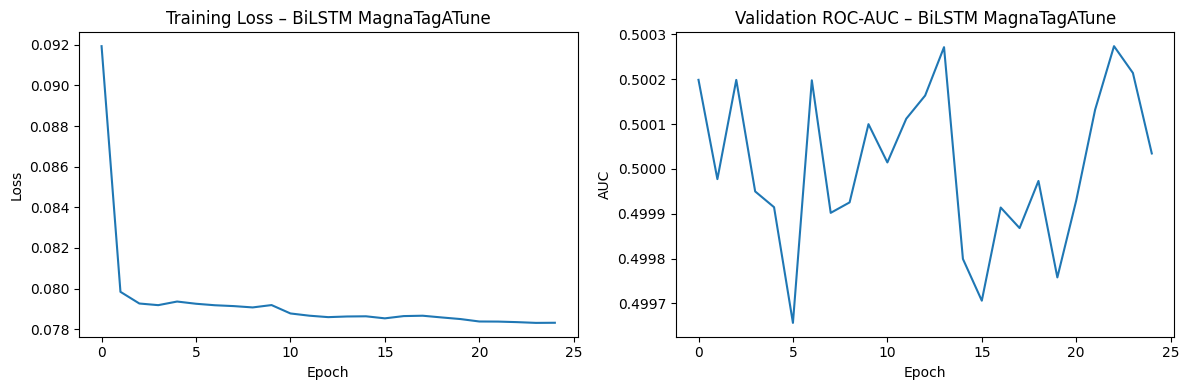

In [10]:
# Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses)
ax1.set_title("Training Loss – BiLSTM MagnaTagATune")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")

ax2.plot(val_aucs)
ax2.set_title("Validation ROC-AUC – BiLSTM MagnaTagATune")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC")

plt.tight_layout()
plt.show()

In [11]:
# Per-Tag F1 Score
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs  = inputs.to(device)
        outputs = torch.sigmoid(model(inputs)).cpu().numpy()
        all_preds.append(outputs)
        all_labels.append(labels.numpy())

all_preds    = np.concatenate(all_preds)
all_labels   = np.concatenate(all_labels)
binary_preds = (all_preds >= THRESHOLD).astype(int)

f1_scores = f1_score(all_labels, binary_preds, average=None, zero_division=0)

print("Per-Tag F1 Scores:")
for tag, f1 in sorted(zip(tag_cols, f1_scores), key=lambda x: -x[1]):
    bar = "█" * int(f1 * 30)
    print(f"  {tag:25s} F1: {f1:.3f}  {bar}")

print(f"\nMacro F1:  {f1_score(all_labels, binary_preds, average='macro', zero_division=0):.4f}")
print(f"Macro AUC: {roc_auc_score(all_labels, all_preds, average='macro'):.4f}")

Per-Tag F1 Scores:
  guitar                    F1: 0.314  █████████
  no voice                  F1: 0.000  
  singer                    F1: 0.000  
  duet                      F1: 0.000  
  plucking                  F1: 0.000  
  hard rock                 F1: 0.000  
  world                     F1: 0.000  
  bongos                    F1: 0.000  
  harpsichord               F1: 0.000  
  female singing            F1: 0.000  
  clasical                  F1: 0.000  
  sitar                     F1: 0.000  
  chorus                    F1: 0.000  
  female opera              F1: 0.000  
  male vocal                F1: 0.000  
  vocals                    F1: 0.000  
  clarinet                  F1: 0.000  
  heavy                     F1: 0.000  
  silence                   F1: 0.000  
  beats                     F1: 0.000  
  men                       F1: 0.000  
  woodwind                  F1: 0.000  
  funky                     F1: 0.000  
  no strings                F1: 0.000  
  chimes    

In [12]:
# Play a MagnatagATune Sample
print("=== MagnaTagATune Audio Sample ===\n")

magna_root  = "data/raw/magnatagatune/Data"
sample_row  = anno.iloc[0]
sample_path = os.path.join(magna_root, sample_row['mp3_path'])
sample_tags = [tag for tag in tag_cols if sample_row[tag] == 1]

print(f"File: {sample_row['mp3_path']}")
print(f"Tags: {sample_tags}")
y_sample, sr_sample = librosa.load(sample_path, sr=22050)
ipd.display(ipd.Audio(y_sample, rate=sr_sample))

=== MagnaTagATune Audio Sample ===

File: f/american_bach_soloists-j_s__bach_solo_cantatas-01-bwv54__i_aria-30-59.mp3
Tags: ['classical', 'strings', 'opera', 'violin']


In [13]:
# Run a Single Sample Through the BiLSTM
print("=== Single Sample Prediction ===\n")

y_audio, _ = librosa.load(sample_path, sr=TARGET_SR)
if len(y_audio) < SAMPLES_PER_TRACK:
    y_audio = np.pad(y_audio, (0, SAMPLES_PER_TRACK - len(y_audio)))
else:
    y_audio = y_audio[:SAMPLES_PER_TRACK]

mel     = librosa.feature.melspectrogram(y=y_audio, sr=TARGET_SR, n_mels=N_MELS)
log_mel = librosa.power_to_db(mel, ref=np.max)
log_mel = log_mel.T
log_mel = (log_mel - mean) / (std + 1e-8)

model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

input_tensor = torch.tensor(log_mel).unsqueeze(0).float().to(device)

with torch.no_grad():
    output = torch.sigmoid(model(input_tensor)).cpu().numpy()[0]

predicted_tags = [(tag, prob) for tag, prob in zip(tag_cols, output) if prob >= THRESHOLD]
predicted_tags = sorted(predicted_tags, key=lambda x: -x[1])

print(f"File: {sample_row['mp3_path']}")
print(f"True Tags:      {sample_tags}\n")
print("Predicted Tags:")
for tag, prob in predicted_tags:
    bar = "█" * int(prob * 30)
    print(f"  {tag:25s} {prob*100:5.1f}%  {bar}")

if not predicted_tags:
    print("  No tags predicted above threshold.")

=== Single Sample Prediction ===

File: f/american_bach_soloists-j_s__bach_solo_cantatas-01-bwv54__i_aria-30-59.mp3
True Tags:      ['classical', 'strings', 'opera', 'violin']

Predicted Tags:
  guitar                     20.7%  ██████


In [ ]:
# Upload Your Own Audio * Predict
from google.colab import files

print("=== Upload Your Own Audio ===\n")
print("Upload an mp3 or wav file to get tag predictions.")

uploaded    = files.upload()
upload_path = list(uploaded.keys())[0]

y_up, sr_up = librosa.load(upload_path, sr=22050)
print(f"\nPlaying: {upload_path}")
ipd.display(ipd.Audio(y_up, rate=sr_up))

y_full, _ = librosa.load(upload_path, sr=TARGET_SR)
if len(y_full) < SAMPLES_PER_TRACK:
    y_full = np.pad(y_full, (0, SAMPLES_PER_TRACK - len(y_full)))
else:
    y_full = y_full[:SAMPLES_PER_TRACK]

mel     = librosa.feature.melspectrogram(y=y_full, sr=TARGET_SR, n_mels=N_MELS)
log_mel = librosa.power_to_db(mel, ref=np.max)
log_mel = log_mel.T
log_mel = (log_mel - mean) / (std + 1e-8)

input_tensor = torch.tensor(log_mel).unsqueeze(0).float().to(device)

with torch.no_grad():
    output = torch.sigmoid(model(input_tensor)).cpu().numpy()[0]

predicted_tags = [(tag, prob) for tag, prob in zip(tag_cols, output) if prob >= THRESHOLD]
predicted_tags = sorted(predicted_tags, key=lambda x: -x[1])

print("\nPredicted Tags:")
for tag, prob in predicted_tags:
    bar = "█" * int(prob * 30)
    print(f"  {tag:25s} {prob*100:5.1f}%  {bar}")

if not predicted_tags:
    print("  No tags predicted above threshold.")

=== Upload Your Own Audio ===

Upload an mp3 or wav file to get tag predictions.
